In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [103]:
import pandas as pd

df = pd.read_csv("CodeAlpha_Task1_Book_Dataset.csv")

print("Dataset loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

display(df.head())

Dataset loaded successfully!
Rows: 20
Columns: 4


,Book Title,Price,Availability,Rating
0,A Light in the Attic,51.77,In stock,Three
1,Tipping the Velvet,53.74,In stock,One
2,Soumission,50.10,In stock,One
3,Sharp Objects,47.82,In stock,Four
4,Sapiens: A Brief History of Humankind,54.23,In stock,Five


In [104]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Dataset Shape:
(20, 4)

Column Names:
['Book Title', 'Price', 'Availability', 'Rating']

Data Types:
Book Title       object
Price           float64
Availability     object
Rating           object
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Book Title    20 non-null     object 
 1   Price         20 non-null     float64
 2   Availability  20 non-null     object 
 3   Rating        20 non-null     object 
dtypes: float64(1), object(3)
memory usage: 772.0+ bytes


In [105]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Book Title      0
Price           0
Availability    0
Rating          0
dtype: int64


In [106]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [107]:
print("Average Price:", round(df["Price"].mean(), 2))
print("Minimum Price:", round(df["Price"].min(), 2))
print("Maximum Price:", round(df["Price"].max(), 2))

print("\nCheapest Book:")
print(df.loc[df["Price"].idxmin(), ["Book Title", "Price"]])

print("\nMost Expensive Book:")
print(df.loc[df["Price"].idxmax(), ["Book Title", "Price"]])

Average Price: 38.05
Minimum Price: 13.99
Maximum Price: 57.25

Cheapest Book:
Book Title    Starving Hearts (Triangular Trade Trilogy, #1)
Price                                                  13.99
Name: 10, dtype: object

Most Expensive Book:
Book Title    Our Band Could Be Your Life: Scenes from the A...
Price                                                     57.25
Name: 15, dtype: object


In [108]:
print("Rating Distribution:")
print(df["Rating"].value_counts())

Rating Distribution:
Rating
One      6
Five     4
Four     4
Three    3
Two      3
Name: count, dtype: int64


In [109]:
rating_price = df.groupby("Rating")["Price"].mean().round(2)

print("Average Price by Rating:")
print(rating_price)

Average Price by Rating:
Rating
Five     39.75
Four     31.10
One      40.02
Three    42.32
Two      36.83
Name: Price, dtype: float64


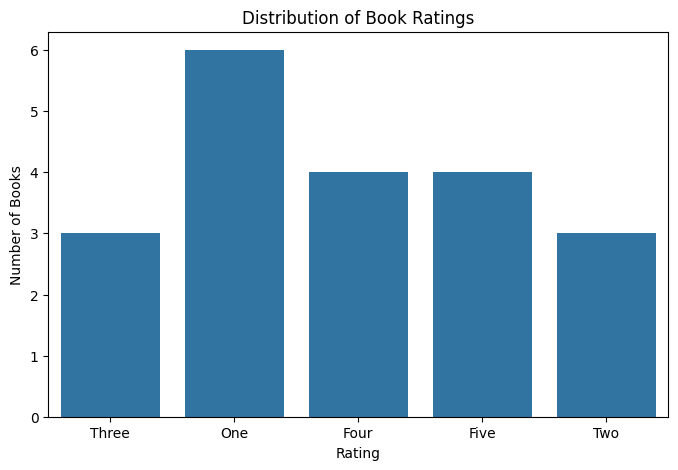

In [110]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Rating")

plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.title("Distribution of Book Ratings")

plt.show()

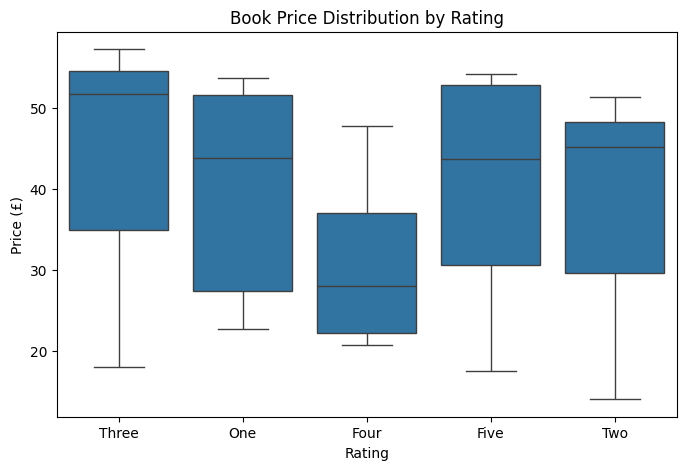

In [111]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Rating", y="Price")

plt.xlabel("Rating")
plt.ylabel("Price (£)")
plt.title("Book Price Distribution by Rating")

plt.show()

In [112]:
Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["Price"] < lower_limit) |
    (df["Price"] > upper_limit)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

print("\nLower limit:", lower_limit)
print("Upper limit:", upper_limit)

print("\nNumber of outliers:", len(outliers))

display(outliers[["Book Title", "Price", "Rating"]])

Q1: 22.6375
Q3: 51.865
IQR: 29.227500000000003

Lower limit: -21.203750000000003
Upper limit: 95.70625000000001

Number of outliers: 0


,Book Title,Price,Rating


In [113]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating_Numeric"] = df["Rating"].map(rating_map)

correlation = df["Price"].corr(df["Rating_Numeric"])

print("Price-Rating Correlation:", round(correlation, 3))

Price-Rating Correlation: -0.076


In [114]:
print("===== EDA FINDINGS =====")

print("Total books analyzed:", len(df))
print("Average price:", round(df["Price"].mean(), 2))
print("Minimum price:", round(df["Price"].min(), 2))
print("Maximum price:", round(df["Price"].max(), 2))

print("\nMost common rating:")
print(df["Rating"].value_counts().idxmax())

print("\nNumber of price outliers:", len(outliers))

print("\nPrice-Rating correlation:",
      round(correlation, 3))

===== EDA FINDINGS =====
Total books analyzed: 20
Average price: 38.05
Minimum price: 13.99
Maximum price: 57.25

Most common rating:
One

Number of price outliers: 0

Price-Rating correlation: -0.076


In [115]:
df.to_csv("CodeAlpha_Task2_EDA_Dataset.csv", index=False)

print("Task 2 EDA dataset saved successfully!")

Task 2 EDA dataset saved successfully!
